<a href="https://colab.research.google.com/github/sidhantmaurya/machine-learning-algos/blob/main/Ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

In [ ]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [ ]:
x= data.data
y=data.target


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=45)


In [ ]:
from sklearn.linear_model import LinearRegression
l=LinearRegression()

In [ ]:
l.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=l.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error
print("r2 score",r2_score(y_test,y_pred))
print("mean square error",mean_squared_error(y_test,y_pred))

r2 score 0.5188113124539249
mean square error 2374.333939618319


In [ ]:
from sklearn.linear_model import Ridge
r= Ridge(alpha=0.0001)

In [ ]:
r.fit(x_train,y_train)

Ridge(alpha=0.0001)

In [ ]:
y_pred1=r.predict(x_test)

In [ ]:
print("r2 square",r2_score(y_test,y_pred1))
print("RMSE",mean_squared_error(y_test,y_pred1))

r2 square 0.5189732635884949
RMSE 2373.534822587263


In [ ]:
from sklearn.datasets import make_regression

In [ ]:
X,Y = make_regression(n_samples=100,n_features=1,n_informative=1, n_targets=1, noise=20,random_state=13)

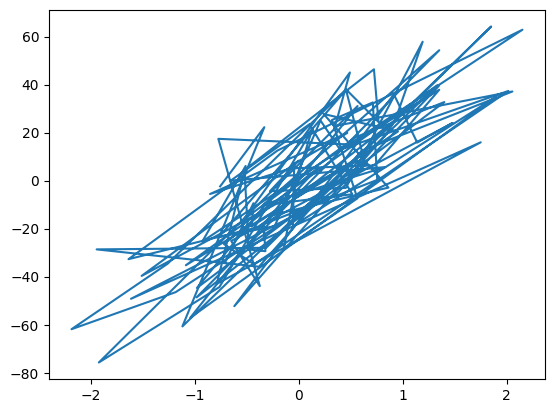

In [ ]:
plt.plot(X,Y)

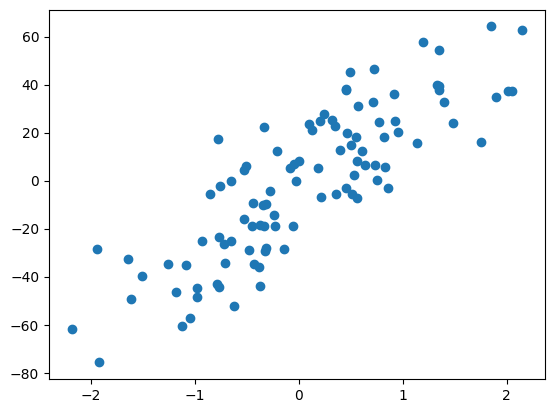

In [ ]:
plt.scatter(X,Y)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr=LinearRegression()
lr.fit(X,Y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
from scipy.optimize import ridder
rr= Ridge(alpha=10)
rr.fit(X,Y)
print(rr.intercept_)
print(rr.coef_)

-2.1269130035235735
[24.9546267]


In [ ]:
rr1=Ridge(alpha=100)
rr1.fit(X,Y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


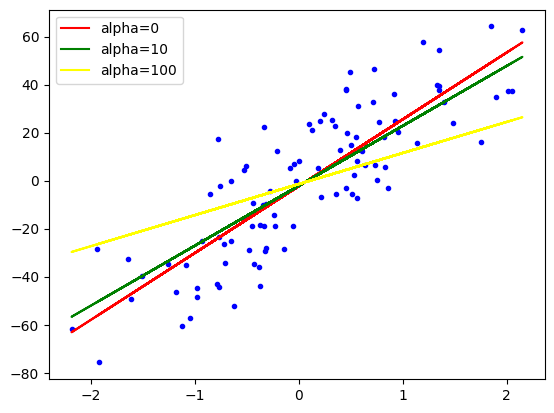

In [ ]:
plt.plot(X,Y,"b.")
plt.plot(X,lr.predict(X),color="red",label="alpha=0")
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='yellow',label='alpha=100')
plt.legend()

mera ridge function


In [ ]:
class mera_ridge:
  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.b=None
    self.m=None

  def fit(self,X_train,Y_train):
    neu=0
    den=0
    for i in range(X_train.shape[0]):
      neu=neu+(Y_train[i]-Y_train.mean())*(X_train[i]-X_train.mean())
      den=den+(X_train[i]-X_train.mean())*(X_train[i]-X_train.mean())

    self.m=neu/(den+self.alpha)
    self.b=Y_train.mean() - (self.m*X_train.mean())

    print(self.m,self.b)

    def predict(X_test):
      pass

In [ ]:
ridge=mera_ridge(alpha=10)


In [ ]:
ridge.fit(X,Y)

[24.9546267] [-2.126913]


gradient descent




In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np


In [ ]:
X,y = load_diabetes(return_X_y=True)
from sklearn.model_selection import train_test_split


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)


In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
reg= SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)

In [ ]:
reg.fit(X_train,y_train)

y_pred=reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4496519367163665
[  50.57247039 -135.28319592  350.47454724  259.3507604     4.24083782
  -46.67206836 -166.49073162  139.49302864  316.78158476  106.18406191]
[150.70800364]
